# 使用Pytorch实现空洞卷积实验
韩佳轩，23281106，计算机科学与技术学院

In [2]:
import torch
import torchvision
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import pickle
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

## 设置空洞卷积训练

In [3]:
class DilatedConvModule(nn.Module):
    def __init__(self):
        super(DilatedConvModule, self).__init__()
        # 定义一个空洞率为1,2,5的三层空洞卷积
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, 
                      kernel_size=3, stride=1, 
                      padding=0, dilation=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, stride=1,
                      padding=0, dilation=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=128, 
                      kernel_size=3, stride=1, 
                      padding=0, dilation=5),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        # 输出层，将通道数变为分类数量
        self.fc = nn.Linear(128, num_classes)

    def forward(self, X):
        # 图片先经过三层空洞卷积
        out = self.conv(X)
        # 使用平均池化层将图片的大小变为1x1
        out = F.avg_pool2d(out, 16)
        # 将张量out从shape batch x 128 x 1 x 1 变为 batch x 128
        out = out.squeeze()
        # 输入到全连接层将输出的维度变为10
        out = self.fc(out)
        return out

In [4]:
def train_epoch(net, data_loader, device):
    
    net.train() # 指定当前为训练模式
    train_batch_num = len(data_loader) # 记录共有多少个batch
    total_loss = 0 # 记录Loss
    correct = 0  # 记录共有多少个样本被正确分类
    sample_num = 0 # 记录样本总数
    
    # 遍历每个batch进行训练
    for batch_idx, (data, target) in enumerate(data_loader):
        # 将图片放入指定的device中
        data = data.to(device).float()
        # 将图片标签放入指定的device中
        target = target.to(device).long()
        # 将当前梯度清零
        optimizer.zero_grad()
        # 使用模型计算出结果
        output = net(data)
        # 计算损失
        loss = criterion(output, target)
        # 进行反向传播
        loss.backward()
        optimizer.step()
        # 累加Loss
        total_loss += loss.item()
        # 找出每个样本值最大的idx，即代表预测此图片属于哪个类别
        prediction = torch.argmax(output, 1)
        # 统计预测正确的类别数量
        correct += (prediction == target).sum().item()
        # 累加当前的样本总数
        sample_num += len(prediction)
    # 计算平均的loss与准确率
    loss = total_loss / train_batch_num
    acc = correct / sample_num
    return loss, acc

In [5]:
def test_epoch(net, data_loader, device):
    net.eval() # 指定当前模式为测试模式
    test_batch_num = len(data_loader)
    total_loss = 0
    correct = 0  
    sample_num = 0
    # 指定不进行梯度变化
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(data_loader):
            data = data.to(device).float()
            target = target.to(device).long()
            output = net(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            prediction = torch.argmax(output, 1)
            correct += (prediction == target).sum().item()
            sample_num += len(prediction)
    loss = total_loss / test_batch_num
    acc = correct / sample_num
    return loss, acc

## 导入训练数据

In [6]:
data_dir = './data' # 指定数据的位置
# 定义一个transform操作，用户将torch中的数据转换为可以输入到我们模型的形式
transform = transforms.Compose(
    [transforms.ToTensor(), # 首先将数据转换为Tensor
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) # 将数据进行归一化，前一个参数代表mean，后一个代表std
# 获取cifar-10数据集并进行transform
cifar_train = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
cifar_test = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
# cifar-10数据集对应的10个类别
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
num_classes = 10 # 共十类
epochs = 200 # 训练多少轮
lr = 0.001 # 学习率
batch_size = 512 # batch大小
device = torch.device("cuda:0") # 指定device为0号GPU,若使用cpu则填写 "cpu"
# 生成dataloader
cifar_trainloader = torch.utils.data.DataLoader(cifar_train, batch_size=batch_size,
                                                shuffle=True, num_workers=0)
cifar_testloader = torch.utils.data.DataLoader(cifar_test, batch_size=512,
                                               shuffle=True, num_workers=0)
# 初始化模型
net = DilatedConvModule().to(device)
# 使用多元交叉熵损失
criterion = nn.CrossEntropyLoss()
# 使用Adam优化器
optimizer = optim.Adam(net.parameters(), lr=lr)

In [7]:
# 存储每一个epoch的loss与acc的变化，便于后面可视化
train_loss_list = []
train_acc_list = []
test_loss_list = []
test_acc_list = []

# 进行训练
for epoch in range(epochs):
    # 在训练集上训练
    train_loss, train_acc = train_epoch(net, data_loader=cifar_trainloader, device=device)
    # 在测试集上验证
    test_loss, test_acc = test_epoch(net, data_loader=cifar_testloader, device=device)
    # 保存各个指标
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)
    print(f"epoch:{epoch}\t train_loss:{train_loss:.4f} \t"
          f"train_acc:{train_acc} \t"
          f"test_loss:{test_loss:.4f} \t test_acc:{test_acc}")

epoch:0	 train_loss:1.5933 	train_acc:0.43094 	test_loss:1.3629 	 test_acc:0.5235
epoch:1	 train_loss:1.2107 	train_acc:0.57446 	test_loss:1.1643 	 test_acc:0.583
epoch:2	 train_loss:1.0417 	train_acc:0.63772 	test_loss:1.0135 	 test_acc:0.6442
epoch:3	 train_loss:0.9442 	train_acc:0.6688 	test_loss:0.9585 	 test_acc:0.6623
epoch:4	 train_loss:0.8701 	train_acc:0.69656 	test_loss:0.9082 	 test_acc:0.6821
epoch:5	 train_loss:0.8196 	train_acc:0.71514 	test_loss:0.8686 	 test_acc:0.6987
epoch:6	 train_loss:0.7729 	train_acc:0.73058 	test_loss:0.8499 	 test_acc:0.7019
epoch:7	 train_loss:0.7349 	train_acc:0.74726 	test_loss:0.7948 	 test_acc:0.719
epoch:8	 train_loss:0.7077 	train_acc:0.75644 	test_loss:0.8194 	 test_acc:0.7167
epoch:9	 train_loss:0.6789 	train_acc:0.76578 	test_loss:0.7722 	 test_acc:0.7328
epoch:10	 train_loss:0.6495 	train_acc:0.77556 	test_loss:0.7177 	 test_acc:0.7515
epoch:11	 train_loss:0.6268 	train_acc:0.78504 	test_loss:0.7234 	 test_acc:0.7488
epoch:12	 train_l

## 绘制实验结果

In [8]:
res = [train_loss_list, train_acc_list, test_loss_list,test_acc_list]

In [9]:
with open('dilation.pkl', 'wb') as f:
    pickle.dump(res, f)

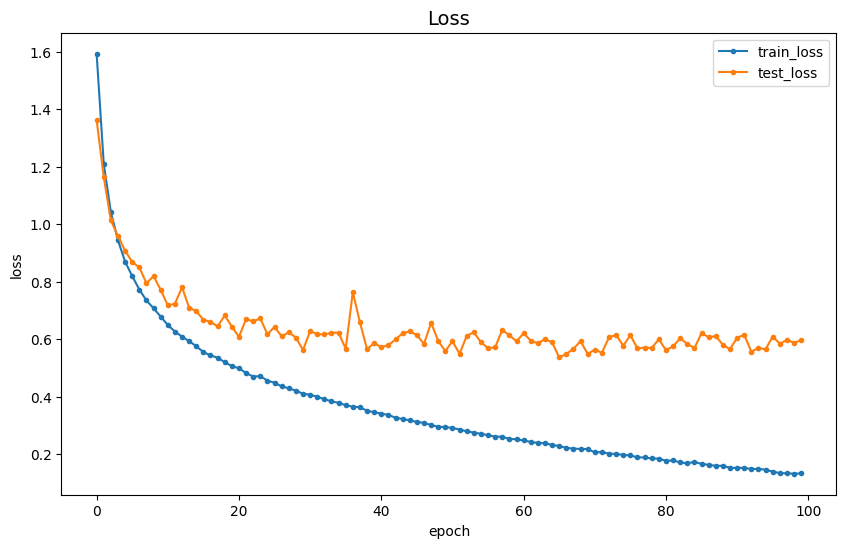

In [10]:
plt.figure(figsize=(10, 6))
train, = plt.plot(train_loss_list[:100],'.-',label='train_loss')
test, = plt.plot(test_loss_list[:100],'.-',label='test_loss')
plt.title("Loss",fontsize=14)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend([train,test],["train_loss", "test_loss"],loc='upper right')
plt.show()

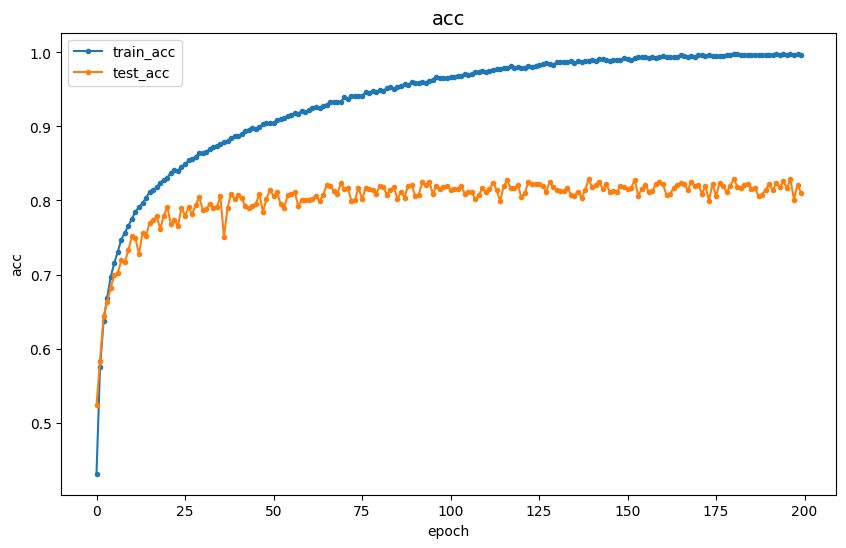

In [11]:
plt.figure(figsize=(10, 6))
train, = plt.plot(train_acc_list,'.-',label='train_acc')
test, = plt.plot(test_acc_list,'.-',label='test_acc')
plt.title("acc",fontsize=14)
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend([train,test],["train_acc", "test_acc"],loc='upper left')
plt.show()

空洞卷积在训练时间上要比卷积时间长，其预测精度有所提升，Loss变化较为稳定，呈现出过拟合的抗力。